In [1]:
import os

# Подивимось на структуру папок датасету
data_path = "/kaggle/input"

for dirname, _, filenames in os.walk(data_path):
    # Показуємо тільки назви папок (класи), не всі файли
    level = dirname.replace(data_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(dirname)}/')
    if level >= 2:  # не заглиблюємось далі 2 рівнів
        continue

input/
  datasets/
    sshikamaru/
      fruit-recognition/
        test/
          test/
        train/
          train/
            Orange/
            Tomato/
            Passion Fruit/
            Cucumber Ripe/
            Cactus fruit/
            Pomegranate/
            Plum/
            Pineapple/
            Papaya/
            Potato Red/
            Kiwi/
            Limes/
            Apple Braeburn/
            Pear/
            Onion White/
            Strawberry/
            Grape Blue/
            Blueberry/
            Apple Granny Smith/
            Apricot/
            Pepper Red/
            Clementine/
            Lemon/
            Avocado/
            Raspberry/
            Cantaloupe/
            Peach/
            Corn/
            Banana/
            Cherry/
            Pepper Green/
            Watermelon/
            Mango/


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torch.nn as nn
import time

# Трансформації — розмір 64×64 (менше ніж 224 → швидше тренування)
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Шлях до даних
train_path = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train/"

# GPU пристрій
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Пристрій: {device}")

Пристрій: cuda


In [3]:
#  Розбиття даних (як на уроці з dog-breeds)

# Повний датасет з двома варіантами трансформацій
full_dataset = datasets.ImageFolder(train_path, transform=train_transform)
full_dataset_test = datasets.ImageFolder(train_path, transform=test_transform)

# Фіксуємо seed для однакового розбиття (однаково для PyTorch і TensorFlow!)
torch.manual_seed(42)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# Генеруємо індекси один раз для обох фреймворків
indices = torch.randperm(len(full_dataset)).tolist()
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Train — з аугментацією, Test — без аугментації
train_dataset = Subset(full_dataset, train_indices)
test_dataset = Subset(full_dataset_test, test_indices)

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Параметри
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

print(f"Тренувальних: {len(train_dataset)}")
print(f"Тестових: {len(test_dataset)}")
print(f"Класів: {num_classes} → {class_names}")

Тренувальних: 13483
Тестових: 3371
Класів: 33 → ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


In [4]:
# Подивимось на перший зразок
img, label = full_dataset[0]
print(f"Тип: {type(img)}")
print(f"Форма тензора: {img.shape}")  # [C, H, W] = [3, 224, 224]
print(f"Мітка (індекс): {label}")
print(f"Назва класу: {full_dataset.classes[label]}")

# Перший зразок з кожного класу (до 5 класів)
shown_classes = set()
for i in range(len(full_dataset)):
    img, label = full_dataset[i]
    if label not in shown_classes:
        print(f"Зразок [{i}]: форма {img.shape}, мітка: {label} → {full_dataset.classes[label]}")
        shown_classes.add(label)
    if len(shown_classes) >= 5:
        break

Тип: <class 'torch.Tensor'>
Форма тензора: torch.Size([3, 64, 64])
Мітка (індекс): 0
Назва класу: Apple Braeburn
Зразок [0]: форма torch.Size([3, 64, 64]), мітка: 0 → Apple Braeburn
Зразок [492]: форма torch.Size([3, 64, 64]), мітка: 1 → Apple Granny Smith
Зразок [984]: форма torch.Size([3, 64, 64]), мітка: 2 → Apricot
Зразок [1476]: форма torch.Size([3, 64, 64]), мітка: 3 → Avocado
Зразок [1903]: форма torch.Size([3, 64, 64]), мітка: 4 → Banana


In [5]:

# Візуалізація - Перевірка
for images, labels in train_loader:
    print(f"Форма батчу зображень: {images.shape}")  # [batch_size, 3, 224, 224]
    print(f"Форма батчу міток: {labels.shape}")       # [batch_size]
    break  # Виводимо тільки перший батч

Форма батчу зображень: torch.Size([32, 3, 64, 64])
Форма батчу міток: torch.Size([32])


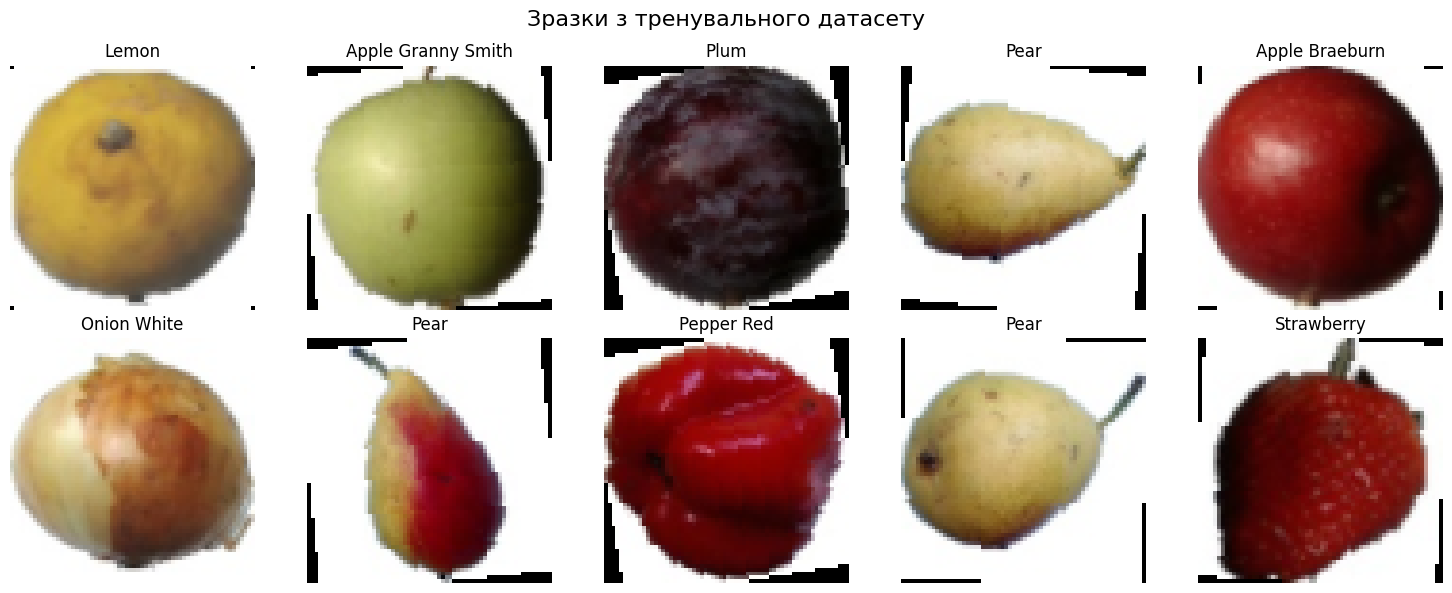

In [6]:
# Візуалізація кількох зразків з тренувального набору
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # Конвертуємо тензор [C, H, W] → [H, W, C] для matplotlib
    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(full_dataset.classes[label])
    ax.axis('off')

plt.suptitle("Зразки з тренувального датасету", fontsize=16)
plt.tight_layout()
plt.show()

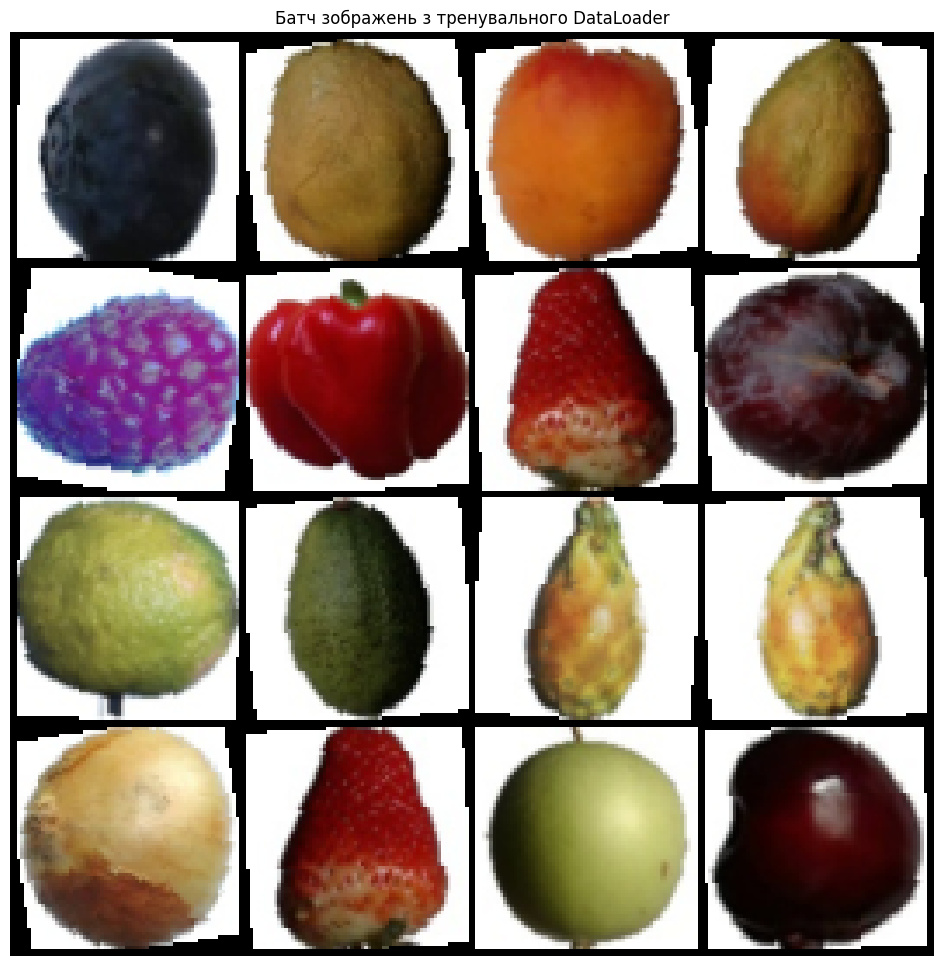

Мітки: ['Blueberry', 'Papaya', 'Apricot', 'Papaya', 'Raspberry', 'Pepper Red', 'Strawberry', 'Plum', 'Limes', 'Avocado', 'Cactus fruit', 'Cactus fruit', 'Onion White', 'Strawberry', 'Apple Granny Smith', 'Cherry']


In [7]:
# Отримуємо один батч
images, labels = next(iter(train_loader))

# Створюємо сітку зображень
grid = make_grid(images[:16], nrow=4, padding=2)

# Відображаємо
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Батч зображень з тренувального DataLoader")
plt.axis('off')
plt.show()

# Виводимо мітки
print("Мітки:", [full_dataset.classes[l] for l in labels[:16].tolist()])

In [8]:
 # CNN модель (PyTorch)

class FruitCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            # Блок 1: 3×64×64 → 8×32×32
            nn.Conv2d(3, 8, kernel_size=3, padding='same'),    # 3→8 каналів, фільтр 3×3
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),             # 64→32

            # Блок 2: 8×32×32 → 16×16×16
            nn.Conv2d(8, 16, kernel_size=3, padding='same'),   # 8→16 каналів
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),             # 32→16

            # Блок 3: 16×16×16 → 32×8×8
            nn.Conv2d(16, 32, kernel_size=3, padding='same'),  # 16→32 каналів
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),             # 16→8

            # Класифікатор
            nn.Flatten(),                                       # 32×8×8 = 2048
            nn.Linear(32 * 8 * 8, 128),                        # 2048→128
            nn.ReLU(),
            nn.Linear(128, num_classes),                        # 128→33
        )

    def forward(self, x):
        return self.model(x)

model_pt = FruitCNN(num_classes).to(device)
print("=== PyTorch CNN ===")
print(model_pt)

=== PyTorch CNN ===
FruitCNN(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=2048, out_features=128, bias=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=33, bias=True)
  )
)


In [9]:
 # Перевірка моделі PyTorch
images, labels = next(iter(train_loader))
images = images.to(device)

output = model_pt(images)
print(f"Вхід:   {images.shape}")     # [32, 3, 64, 64]
print(f"Вихід:  {output.shape}")     # [32, 33]

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"Параметрів: {count_params(model_pt):,}")

Вхід:   torch.Size([32, 3, 64, 64])
Вихід:  torch.Size([32, 33])
Параметрів: 272,561


In [10]:
# Тренування PyTorch

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)
epochs = 10

train_losses_pt = []
train_accs_pt = []
val_losses_pt = []
val_accs_pt = []

print("=== Тренування: PyTorch CNN ===")
start_time = time.time()

for epoch in range(epochs):
    # --- Train ---
    model_pt.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses_pt.append(train_loss)
    train_accs_pt.append(train_acc)

    # --- Validation ---
    model_pt.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_pt(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc = val_correct / val_total
    val_losses_pt.append(val_loss)
    val_accs_pt.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

pt_time = time.time() - start_time
print(f"\nЧас тренування: {pt_time:.1f} сек")

=== Тренування: PyTorch CNN ===
Epoch [1/10] Train Loss: 0.9446 Acc: 0.7099 | Val Loss: 0.2039 Acc: 0.9318
Epoch [2/10] Train Loss: 0.1596 Acc: 0.9480 | Val Loss: 0.1569 Acc: 0.9469
Epoch [3/10] Train Loss: 0.0554 Acc: 0.9838 | Val Loss: 0.0592 Acc: 0.9748
Epoch [4/10] Train Loss: 0.0679 Acc: 0.9783 | Val Loss: 0.0596 Acc: 0.9769
Epoch [5/10] Train Loss: 0.0408 Acc: 0.9879 | Val Loss: 0.0304 Acc: 0.9905
Epoch [6/10] Train Loss: 0.0388 Acc: 0.9869 | Val Loss: 0.0580 Acc: 0.9778
Epoch [7/10] Train Loss: 0.0435 Acc: 0.9884 | Val Loss: 0.0021 Acc: 0.9997
Epoch [8/10] Train Loss: 0.0015 Acc: 0.9999 | Val Loss: 0.0016 Acc: 0.9994
Epoch [9/10] Train Loss: 0.0273 Acc: 0.9912 | Val Loss: 0.0795 Acc: 0.9760
Epoch [10/10] Train Loss: 0.0290 Acc: 0.9907 | Val Loss: 0.0095 Acc: 0.9979

Час тренування: 327.9 сек


PyTorch CNN Test Accuracy: 0.9979 (3364/3371)

=== Classification Report (PyTorch) ===
                    precision    recall  f1-score   support

    Apple Braeburn      1.000     1.000     1.000       100
Apple Granny Smith      1.000     1.000     1.000        75
           Apricot      1.000     1.000     1.000       101
           Avocado      1.000     1.000     1.000        78
            Banana      1.000     1.000     1.000       109
         Blueberry      1.000     1.000     1.000        80
      Cactus fruit      1.000     1.000     1.000       102
        Cantaloupe      1.000     1.000     1.000       120
            Cherry      1.000     1.000     1.000       110
        Clementine      1.000     1.000     1.000       107
              Corn      1.000     1.000     1.000        89
     Cucumber Ripe      1.000     1.000     1.000        81
        Grape Blue      1.000     1.000     1.000       197
              Kiwi      1.000     1.000     1.000       102
            

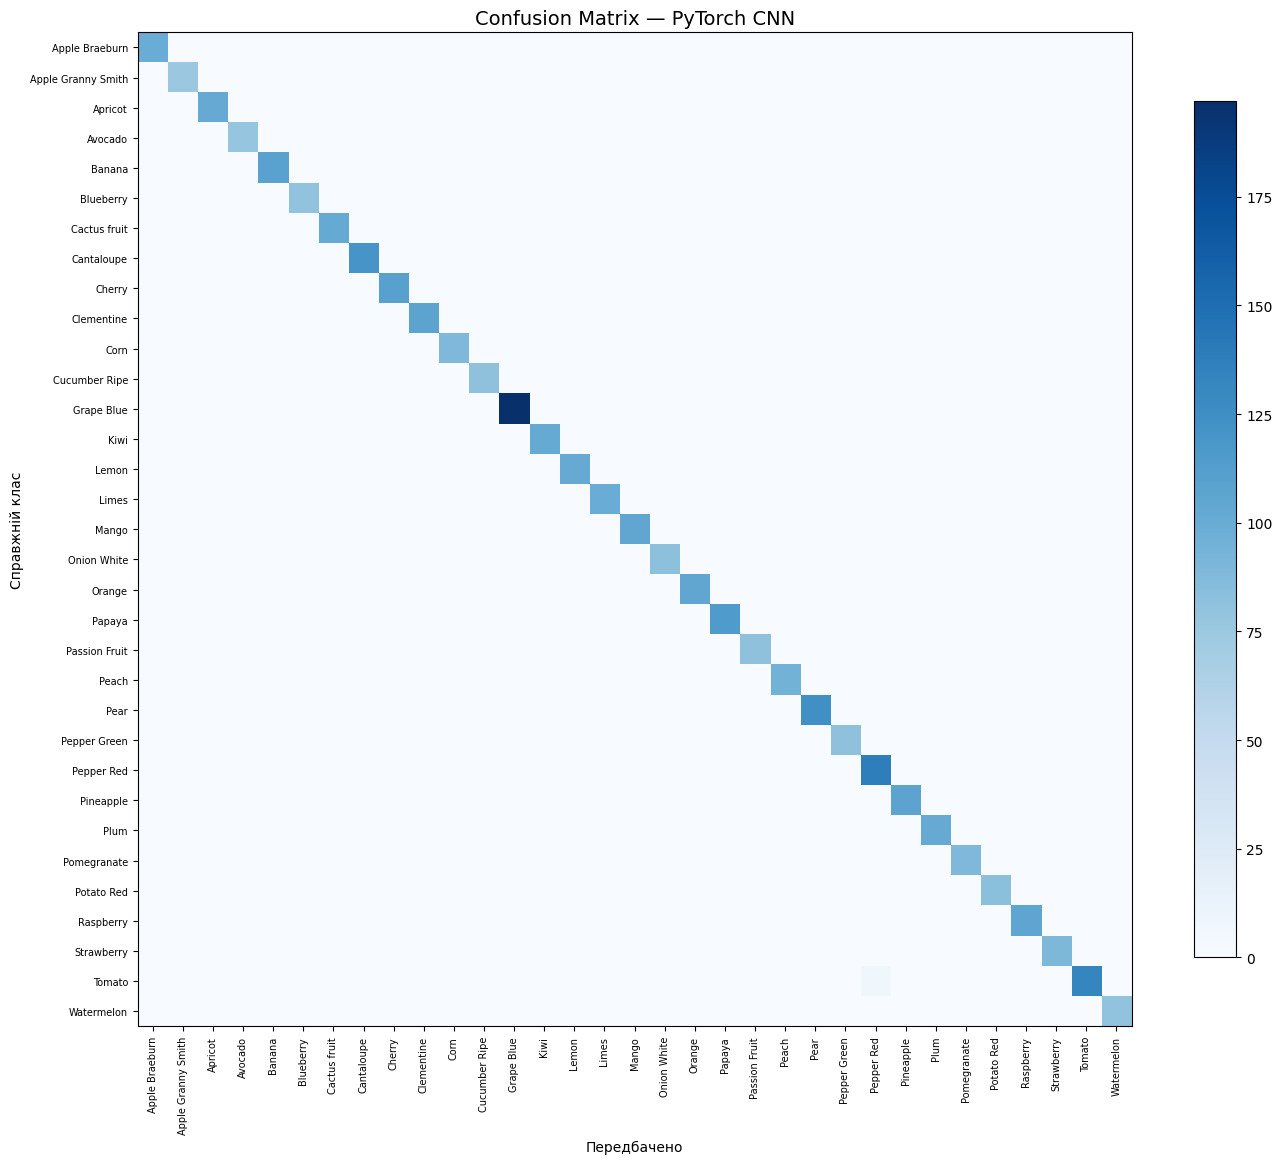

In [11]:
# Тестування + Confusion Matrix (PyTorch)

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

model_pt.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_pt(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Точність
pt_test_acc = (all_preds == all_labels).mean()
print(f"PyTorch CNN Test Accuracy: {pt_test_acc:.4f} ({(all_preds == all_labels).sum()}/{len(all_labels)})")

# Classification Report
print("\n=== Classification Report (PyTorch) ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

# Confusion Matrix
cm_pt = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_pt, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix — PyTorch CNN', fontsize=14)
fig.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)
ax.set_xlabel('Передбачено')
ax.set_ylabel('Справжній клас')

plt.tight_layout()
plt.show()

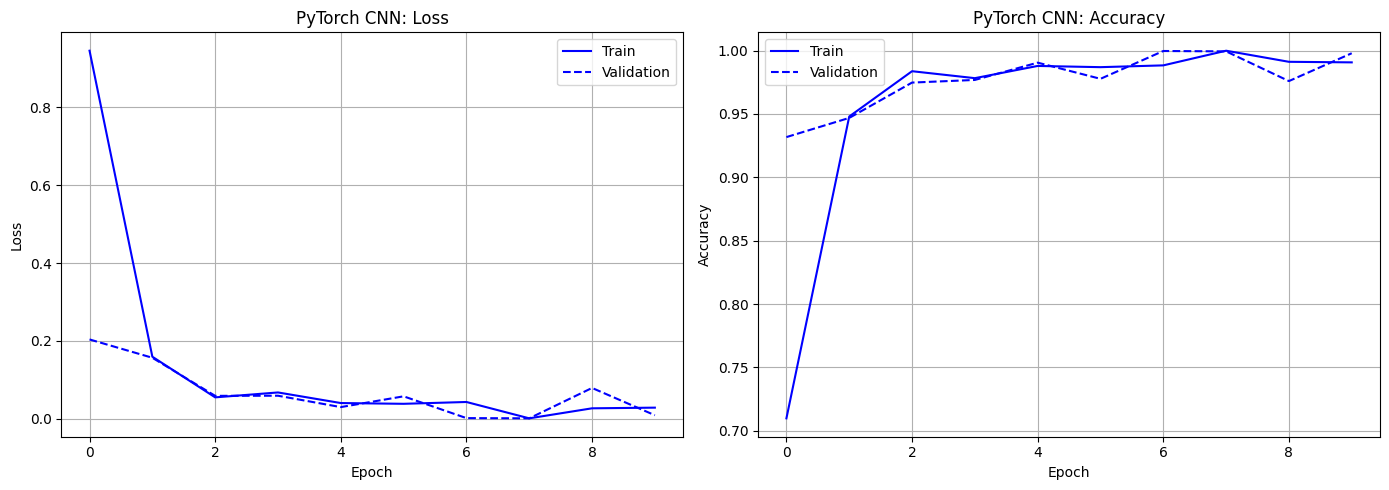

In [12]:
# Графіки PyTorch
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_pt, label='Train', color='blue')
ax1.plot(val_losses_pt, label='Validation', color='blue', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('PyTorch CNN: Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs_pt, label='Train', color='blue')
ax2.plot(val_accs_pt, label='Validation', color='blue', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('PyTorch CNN: Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Варіант 4: TensorFlow + LeakyReLU
# # Старий спосіб:
# model_tf_leaky = keras.Sequential([
#     layers.Flatten(input_shape=input_shape, name='flatten'),
#     layers.Dense(512, name='dense_1'),
#     layers.LeakyReLU(negative_slope=0.01, name='leaky_1'),
#     ...
# ], name='FruitNet_LeakyReLU')

# Новий спосіб:
model_tf_leaky = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(name='flatten'),
    layers.Dense(512, name='dense_1'),
    layers.LeakyReLU(negative_slope=0.01, name='leaky_1'),
    layers.Dense(256, name='dense_2'),
    layers.LeakyReLU(negative_slope=0.01, name='leaky_2'),
    layers.Dense(128, name='dense_3'),
    layers.LeakyReLU(negative_slope=0.01, name='leaky_3'),
    layers.Dense(num_classes_tf, activation='softmax', name='output'),
], name='FruitNet_LeakyReLU')

model_tf_leaky.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== TensorFlow + LeakyReLU ===")
model_tf_leaky.summary()

In [ ]:
 # Перевірка обох моделей TensorFlow

for images, labels in train_tf.take(1):
    output_relu = model_tf_relu(images)
    output_leaky = model_tf_leaky(images)

    print(f"Вхід:             {images.shape}")
    print(f"Вихід ReLU:       {output_relu.shape}")
    print(f"Вихід LeakyReLU:  {output_leaky.shape}")

print(f"\nПараметрів ReLU:      {model_tf_relu.count_params():,}")
print(f"Параметрів LeakyReLU: {model_tf_leaky.count_params():,}")

In [ ]:
# Тренування PyTorch + ReLU
import time

# Налаштування
criterion = nn.CrossEntropyLoss()
optimizer_relu = torch.optim.Adam(model_relu.parameters(), lr=0.001)
epochs = 10

# Списки для збереження метрик
train_losses_relu = []
train_accs_relu = []

print("=== Тренування: PyTorch + ReLU ===")
start_time = time.time()

for epoch in range(epochs):
    model_relu.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_relu(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer_relu.zero_grad()
        loss.backward()
        optimizer_relu.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses_relu.append(epoch_loss)
    train_accs_relu.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.4f}")

relu_time = time.time() - start_time
print(f"\nЧас тренування ReLU: {relu_time:.1f} сек")

###=== Тренування: PyTorch + ReLU ===
    Epoch [1/10] Loss: 1.4112 Accuracy: 0.6381
    Epoch [2/10] Loss: 0.2531 Accuracy: 0.9154
    Epoch [3/10] Loss: 0.1931 Accuracy: 0.9366
    Epoch [4/10] Loss: 0.1199 Accuracy: 0.9601
    Epoch [5/10] Loss: 0.1377 Accuracy: 0.9546
    Epoch [6/10] Loss: 0.1204 Accuracy: 0.9581
    Epoch [7/10] Loss: 0.1243 Accuracy: 0.9617
    Epoch [8/10] Loss: 0.1560 Accuracy: 0.9548
    Epoch [9/10] Loss: 0.0765 Accuracy: 0.9721
    Epoch [10/10] Loss: 0.0549 Accuracy: 0.9822

In [ ]:
# Тренування PyTorch + LeakyReLU
optimizer_leaky = torch.optim.Adam(model_leaky.parameters(), lr=0.001)

train_losses_leaky = []
train_accs_leaky = []

print("=== Тренування: PyTorch + LeakyReLU ===")
start_time = time.time()

for epoch in range(epochs):
    model_leaky.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_leaky(images)
        loss = criterion(outputs, labels)

        optimizer_leaky.zero_grad()
        loss.backward()
        optimizer_leaky.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses_leaky.append(epoch_loss)
    train_accs_leaky.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.4f}")

leaky_time = time.time() - start_time
print(f"\nЧас тренування LeakyReLU: {leaky_time:.1f} сек")

### === Тренування: PyTorch + LeakyReLU ===
    Epoch [1/10] Loss: 1.5527 Accuracy: 0.6045
    Epoch [2/10] Loss: 0.2844 Accuracy: 0.9034
    Epoch [3/10] Loss: 0.1715 Accuracy: 0.9420
    Epoch [4/10] Loss: 0.2013 Accuracy: 0.9334
    Epoch [5/10] Loss: 0.1400 Accuracy: 0.9559
    Epoch [6/10] Loss: 0.1191 Accuracy: 0.9618
    Epoch [7/10] Loss: 0.1402 Accuracy: 0.9587
    Epoch [8/10] Loss: 0.1171 Accuracy: 0.9640
    Epoch [9/10] Loss: 0.0529 Accuracy: 0.9828
    Epoch [10/10] Loss: 0.1785 Accuracy: 0.9540

    Час тренування LeakyReLU: 408.5 сек

In [ ]:
# Тестування PyTorch (обидва варіанти)
def test_pytorch_model(model, test_loader, device, name):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = correct / total
    avg_loss = test_loss / len(test_loader)
    print(f"{name}: Test Loss: {avg_loss:.4f}, Test Accuracy: {acc:.4f} ({correct}/{total})")
    return avg_loss, acc

print("=== Тестування PyTorch ===")
pt_relu_loss, pt_relu_acc = test_pytorch_model(model_relu, test_loader, device, "ReLU")
pt_leaky_loss, pt_leaky_acc = test_pytorch_model(model_leaky, test_loader, device, "LeakyReLU")

### === Тестування PyTorch ===
    ReLU: Test Loss: 0.0360, Test Accuracy: 0.9861 (3324/3371)
    LeakyReLU: Test Loss: 0.0306, Test Accuracy: 0.9896 (3336/3371)

In [ ]:
# Аналіз мертвих нейронів
def count_dead_neurons(model, data_loader, device, name):
    """Рахуємо нейрони які видають 0 на ВСІХ зразках"""
    model.eval()
    
    # Збираємо активації після кожного ReLU/LeakyReLU
    activations = {}
    
    def hook_fn(layer_name):
        def hook(module, input, output):
            if layer_name not in activations:
                activations[layer_name] = []
            activations[layer_name].append((output > 0).float().cpu())
        return hook
    
    # Реєструємо hooks на activation шари
    hooks = []
    for layer_name, module in model.model.named_modules():
        if isinstance(module, (nn.ReLU, nn.LeakyReLU)):
            hooks.append(module.register_forward_hook(hook_fn(layer_name)))
    
    # Прогоняємо дані
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            _ = model(images)
    
    # Видаляємо hooks
    for h in hooks:
        h.remove()
    
    # Аналізуємо: нейрон "мертвий" якщо він = 0 для ВСІХ зразків
    print(f"\n=== Мертві нейрони: {name} ===")
    dead_counts = {}
    total_counts = {}
    
    for layer_name, acts in activations.items():
        combined = torch.cat(acts, dim=0)            # [всі зразки, нейрони]
        alive_ratio = combined.mean(dim=0)            # частка активних для кожного нейрона
        dead = (alive_ratio == 0).sum().item()        # нейрон мертвий = 0% активацій
        total = combined.shape[1]
        dead_counts[layer_name] = dead
        total_counts[layer_name] = total
        print(f"  Шар {layer_name}: {dead}/{total} мертвих ({100*dead/total:.1f}%)")
    
    return dead_counts, total_counts

relu_dead, relu_total = count_dead_neurons(model_relu, test_loader, device, "PyTorch + ReLU")
leaky_dead, leaky_total = count_dead_neurons(model_leaky, test_loader, device, "PyTorch + LeakyReLU")

# Графік
fig, ax = plt.subplots(figsize=(10, 5))

layers_names = [f"Layer {i+1}\n({relu_total[k]} нейронів)" for i, k in enumerate(relu_dead.keys())]
x = range(len(layers_names))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], relu_dead.values(), width, label='ReLU (мертві)', color='tomato')
bars2 = ax.bar([i + width/2 for i in x], leaky_dead.values(), width, label='LeakyReLU (мертві)', color='skyblue')

# Підписи на стовпцях
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, 
                f'{int(bar.get_height())}', ha='center', fontweight='bold')
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{int(bar.get_height())}', ha='center', fontweight='bold')

ax.set_xlabel('Шар')
ax.set_ylabel('Кількість мертвих нейронів')
ax.set_title('Мертві нейрони: ReLU vs LeakyReLU')
ax.set_xticks(x)
ax.set_xticklabels(layers_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### === Мертві нейрони: PyTorch + ReLU ===
      Шар 2: 470/512 мертвих (91.8%)
      Шар 4: 179/256 мертвих (69.9%)
      Шар 6: 51/128 мертвих (39.8%)

### === Мертві нейрони: PyTorch + LeakyReLU ===
      Шар 2: 446/512 мертвих (87.1%)
      Шар 4: 152/256 мертвих (59.4%)
      Шар 6: 60/128 мертвих (46.9%)

[https://drive.google.com/file/d/15fZQKqhQ6AOX6v7OaPVYtKuEWx-MOkjp/view?usp=sharing](http://)

In [ ]:
# Графіки PyTorch
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses_relu, label='ReLU', color='blue')
ax1.plot(train_losses_leaky, label='LeakyReLU', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('PyTorch: Training Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs_relu, label='ReLU', color='blue')
ax2.plot(train_accs_leaky, label='LeakyReLU', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('PyTorch: Training Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Тренування TensorFlow (обидва варіанти)
# Тренування TensorFlow + ReLU
print("=== Тренування: TensorFlow + ReLU ===")
start_time = time.time()

history_tf_relu = model_tf_relu.fit(
    train_tf,
    validation_data=test_tf,
    epochs=10,
    verbose=1
)

tf_relu_time = time.time() - start_time
print(f"\nЧас тренування TF ReLU: {tf_relu_time:.1f} сек")

422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.3874 - loss: 20.4150 - val_accuracy: 0.8973 - val_loss: 0.2825
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9414 - loss: 0.2089 - val_accuracy: 0.8519 - val_loss: 0.4454
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8877 - loss: 0.4225 - val_accuracy: 0.9816 - val_loss: 0.0713
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9679 - loss: 0.1149 - val_accuracy: 0.8697 - val_loss: 0.5246
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9507 - loss: 0.1917 - val_accuracy: 0.9902 - val_loss: 0.0325
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9390 - loss: 0.3049 - val_accuracy: 0.9843 - val_loss: 0.0389
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9570 - loss: 0.1818 - val_accuracy: 0.9929 - val_loss: 0.0248
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9629 - loss: 0.1495 - val_accuracy: 0.9496 - val_loss: 0.1536
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9609 - loss: 0.1721 - val_accuracy: 0.9970 - val_loss: 0.0074
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9920 - loss: 0.0349 - val_accuracy: 0.9680 - val_loss: 0.1169

Час тренування TF ReLU: 98.2 сек

422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.3874 - loss: 20.4150 - val_accuracy: 0.8973 - val_loss: 0.2825
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9414 - loss: 0.2089 - val_accuracy: 0.8519 - val_loss: 0.4454
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8877 - loss: 0.4225 - val_accuracy: 0.9816 - val_loss: 0.0713
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9679 - loss: 0.1149 - val_accuracy: 0.8697 - val_loss: 0.5246
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9507 - loss: 0.1917 - val_accuracy: 0.9902 - val_loss: 0.0325
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9390 - loss: 0.3049 - val_accuracy: 0.9843 - val_loss: 0.0389
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9570 - loss: 0.1818 - val_accuracy: 0.9929 - val_loss: 0.0248
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9629 - loss: 0.1495 - val_accuracy: 0.9496 - val_loss: 0.1536
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9609 - loss: 0.1721 - val_accuracy: 0.9970 - val_loss: 0.0074
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9920 - loss: 0.0349 - val_accuracy: 0.9680 - val_loss: 0.1169

Час тренування TF ReLU: 98.2 сек

In [ ]:
# Тренування TensorFlow + LeakyReLU
print("=== Тренування: TensorFlow + LeakyReLU ===")
start_time = time.time()

history_tf_leaky = model_tf_leaky.fit(
    train_tf,
    validation_data=test_tf,
    epochs=10,
    verbose=1
)

tf_leaky_time = time.time() - start_time
print(f"\nЧас тренування TF LeakyReLU: {tf_leaky_time:.1f} сек")

### === Тренування: TensorFlow + LeakyReLU ===
    Epoch 1/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.3975 - loss: 22.2341 - val_accuracy: 0.9567 - val_loss: 0.1571
    Epoch 2/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9317 - loss: 0.2350 - val_accuracy: 0.9929 - val_loss: 0.0344
    Epoch 3/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9511 - loss: 0.1815 - val_accuracy: 0.9128 - val_loss: 0.3129
    Epoch 4/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9495 - loss: 0.1705 - val_accuracy: 0.9967 - val_loss: 0.0135
    Epoch 5/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9778 - loss: 0.0829 - val_accuracy: 0.9774 - val_loss: 0.0638
    Epoch 6/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9475 - loss: 0.2821 - val_accuracy: 0.9119 - val_loss: 0.3887
    Epoch 7/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9617 - loss: 0.1684 - val_accuracy: 0.9421 - val_loss: 0.2837
    Epoch 8/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9372 - loss: 0.3371 - val_accuracy: 0.9617 - val_loss: 0.2534
    Epoch 9/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9836 - loss: 0.0816 - val_accuracy: 0.9555 - val_loss: 0.2116
    Epoch 10/10
    422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9726 - loss: 0.1264 - val_accuracy: 0.9460 - val_loss: 0.2979

    Час тренування TF LeakyReLU: 91.8 сек

In [ ]:
# Тестування TensorFlow (обидва варіанти)
print("=== Тестування TensorFlow ===")
tf_relu_loss, tf_relu_acc = model_tf_relu.evaluate(test_tf, verbose=0)
tf_leaky_loss, tf_leaky_acc = model_tf_leaky.evaluate(test_tf, verbose=0)

print(f"ReLU:      Test Loss: {tf_relu_loss:.4f}, Test Accuracy: {tf_relu_acc:.4f}")
print(f"LeakyReLU: Test Loss: {tf_leaky_loss:.4f}, Test Accuracy: {tf_leaky_acc:.4f}")

In [ ]:
# Графіки TensorFlow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history_tf_relu.history['loss'], label='ReLU train', color='blue')
ax1.plot(history_tf_relu.history['val_loss'], label='ReLU val', color='blue', linestyle='--')
ax1.plot(history_tf_leaky.history['loss'], label='LeakyReLU train', color='orange')
ax1.plot(history_tf_leaky.history['val_loss'], label='LeakyReLU val', color='orange', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('TensorFlow: Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history_tf_relu.history['accuracy'], label='ReLU train', color='blue')
ax2.plot(history_tf_relu.history['val_accuracy'], label='ReLU val', color='blue', linestyle='--')
ax2.plot(history_tf_leaky.history['accuracy'], label='LeakyReLU train', color='orange')
ax2.plot(history_tf_leaky.history['val_accuracy'], label='LeakyReLU val', color='orange', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('TensorFlow: Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
 # Зведена таблиця результатів
print("=" * 70)
print("ПОРІВНЯННЯ ВСІХ 4 ВАРІАНТІВ")
print("=" * 70)
print(f"{'Варіант':<30} {'Test Loss':<12} {'Test Acc':<12} {'Час (сек)':<10}")
print("-" * 70)
print(f"{'PyTorch + ReLU':<30} {pt_relu_loss:<12.4f} {pt_relu_acc:<12.4f} {relu_time:<10.1f}")
print(f"{'PyTorch + LeakyReLU':<30} {pt_leaky_loss:<12.4f} {pt_leaky_acc:<12.4f} {leaky_time:<10.1f}")
print(f"{'TensorFlow + ReLU':<30} {tf_relu_loss:<12.4f} {tf_relu_acc:<12.4f} {tf_relu_time:<10.1f}")
print(f"{'TensorFlow + LeakyReLU':<30} {tf_leaky_loss:<12.4f} {tf_leaky_acc:<12.4f} {tf_leaky_time:<10.1f}")
print("=" * 70)

# Визначаємо найкращий
results = {
    'PyTorch + ReLU': pt_relu_acc,
    'PyTorch + LeakyReLU': pt_leaky_acc,
    'TensorFlow + ReLU': tf_relu_acc,
    'TensorFlow + LeakyReLU': tf_leaky_acc,
}
best = max(results, key=results.get)
print(f"\n🏆 Найкращий варіант: {best} ({results[best]:.4f})")

======================================================================
ПОРІВНЯННЯ ВСІХ 4 ВАРІАНТІВ
======================================================================
Варіант                        Test Loss    Test Acc     Час (сек) 
----------------------------------------------------------------------
PyTorch + ReLU                 0.0895       0.9703       466.8     
PyTorch + LeakyReLU            0.0120       0.9967       380.7     
TensorFlow + ReLU              0.1477       0.9671       89.7      
TensorFlow + LeakyReLU         0.0520       0.9929       87.3      
======================================================================

🏆 Найкращий варіант: PyTorch + LeakyReLU (0.9967)

In [ ]:
# Фінальний графік: всі 4 варіанти
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Порівняння 4 варіантів нейромережі', fontsize=14, fontweight='bold')

# Loss
ax1.plot(train_losses_relu, label='PT ReLU', color='blue')
ax1.plot(train_losses_leaky, label='PT LeakyReLU', color='cyan')
ax1.plot(history_tf_relu.history['loss'], label='TF ReLU', color='red')
ax1.plot(history_tf_leaky.history['loss'], label='TF LeakyReLU', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs_relu, label='PT ReLU', color='blue')
ax2.plot(train_accs_leaky, label='PT LeakyReLU', color='cyan')
ax2.plot(history_tf_relu.history['accuracy'], label='TF ReLU', color='red')
ax2.plot(history_tf_leaky.history['accuracy'], label='TF LeakyReLU', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()